In [1]:
import pandas as pd
df = pd.read_csv('군집분석용_데이터셋.csv')
df

,지역명,식당 평가 지표,관광 소비 지표,치안 평가 지표,교통접근성 평가 지표
0,강원 강릉시,440.568338,1866.0,3.7385,0.036538
1,강원 고성군,287.425295,530.0,3.7772,0.016667
2,강원 동해시,324.271060,393.0,3.4289,2.183333
3,강원 삼척시,239.659512,507.0,3.3425,0.118787
4,강원 속초시,789.962512,1655.0,3.9321,1.942857
...,...,...,...,...,...
223,충북 진천군,208.586352,526.0,2.6908,1.845209
224,충북 청주시,349.452156,1360.5,NaN,3.682253
225,충북 충주시,188.146014,1240.0,3.4283,1.767040
226,서울 도봉구,562.958880,914.0,2.7175,4.250000


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 228 entries, 0 to 227
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   지역명          228 non-null    object 
 1   식당 평가 지표     228 non-null    float64
 2   관광 소비 지표     228 non-null    float64
 3   치안 평가 지표     226 non-null    float64
 4   교통접근성 평가 지표  226 non-null    float64
dtypes: float64(4), object(1)
memory usage: 9.0+ KB


In [3]:
missing_value_rows = df[df.isnull().any(axis=1)]

# 결측값 있는 행 출력
missing_value_rows

,지역명,식당 평가 지표,관광 소비 지표,치안 평가 지표,교통접근성 평가 지표
7,강원 영월군,263.515090,147.0,3.3334,NaN
94,대구 군위군,348.966726,267.0,NaN,1.574919
218,충북 영동군,224.732341,113.0,2.9142,NaN
224,충북 청주시,349.452156,1360.5,NaN,3.682253


In [4]:
# 결측값 채우기
df.loc[7, '교통접근성 평가 지표'] = 0.7480035492   # 강원 영월군
df.loc[218, '교통접근성 평가 지표'] = 1.027186761  # 충북 영동군

df.loc[94, '치안 평가 지표'] = 3.189
df.loc[224, '치안 평가 지표'] = 3.068

df

,지역명,식당 평가 지표,관광 소비 지표,치안 평가 지표,교통접근성 평가 지표
0,강원 강릉시,440.568338,1866.0,3.7385,0.036538
1,강원 고성군,287.425295,530.0,3.7772,0.016667
2,강원 동해시,324.271060,393.0,3.4289,2.183333
3,강원 삼척시,239.659512,507.0,3.3425,0.118787
4,강원 속초시,789.962512,1655.0,3.9321,1.942857
...,...,...,...,...,...
223,충북 진천군,208.586352,526.0,2.6908,1.845209
224,충북 청주시,349.452156,1360.5,3.0680,3.682253
225,충북 충주시,188.146014,1240.0,3.4283,1.767040
226,서울 도봉구,562.958880,914.0,2.7175,4.250000


In [5]:
df.describe()

,식당 평가 지표,관광 소비 지표,치안 평가 지표,교통접근성 평가 지표
count,228.000000,228.000000,228.000000,228.000000
mean,385.360795,1452.752193,3.017227,8.646419
std,218.302790,1995.543836,0.588411,15.650755
min,87.789516,15.000000,1.330000,0.012101
25%,237.784004,259.250000,2.619450,1.210087
50%,336.507482,838.500000,3.081400,2.867227
75%,455.853758,1868.750000,3.448525,9.115663
max,1418.476366,14933.000000,4.301000,124.800000


In [6]:
df_set = df.set_index('지역명')

In [7]:
from ydata_profiling import ProfileReport
# 클러스터링을 위한 특성을 뽑기위해 프로파일링 진행
profile = ProfileReport(df_set, title="Profiling Report")
profile.to_file('지역_여행_EDA.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

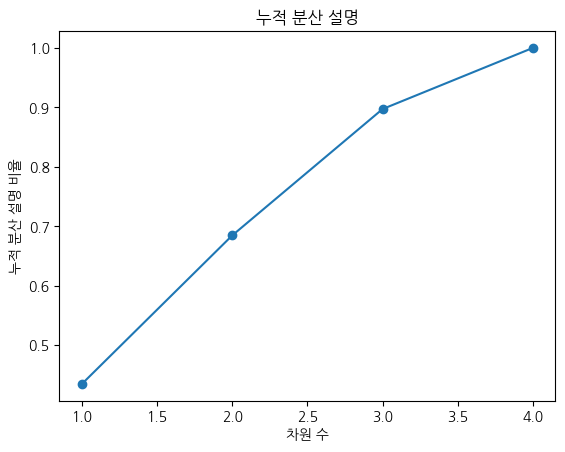

Number of Components: 1, Cumulative Explained Variance: 0.4344
Number of Components: 2, Cumulative Explained Variance: 0.6844
Number of Components: 3, Cumulative Explained Variance: 0.8971
Number of Components: 4, Cumulative Explained Variance: 1.0000


In [8]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
# 축소 차원 결정

%matplotlib inline
# 로그 변환 (0 또는 음수 값을 처리하기 위해 1을 더해줌)
#selected_df_log = np.log1p(selected_df)

# 데이터 정규화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_set)


# PCA 적용
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# 분산 설명 비율
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance_ratio)


# 누적 분산 설명 비율 플롯
plt.rcParams['font.family'] = 'NanumGothic'
plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, marker='o')
plt.title('누적 분산 설명')
plt.xlabel('차원 수')
plt.ylabel('누적 분산 설명 비율')

plt.show()

# 누적 분산 설명 비율 확인
for i, cumulative_variance in enumerate(cumulative_explained_variance):
    print(f'Number of Components: {i+1}, Cumulative Explained Variance: {cumulative_variance:.4f}')

Text(0.5, 1.0, '최적 군집 수 확인을 위한 엘보 시각화')

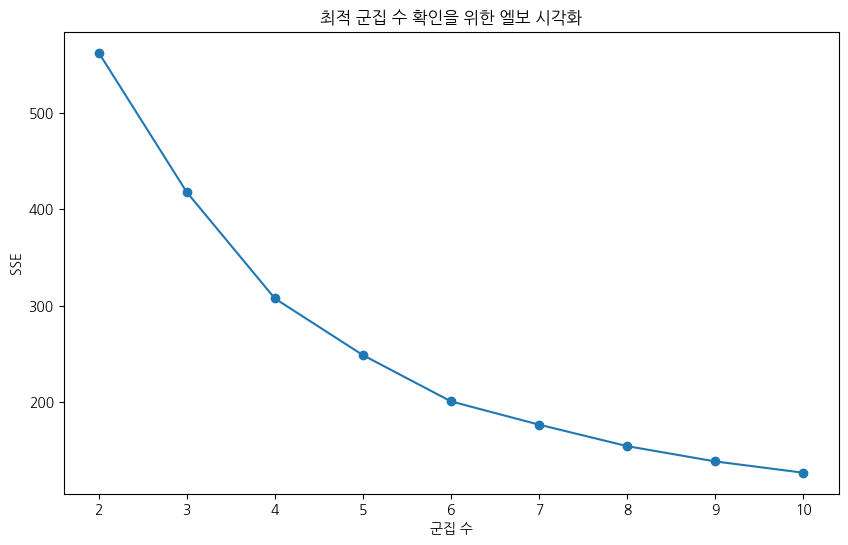

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
# 엘보 시각화

# 데이터 정규화
scaler = StandardScaler()              # 이상치가 많아 표준화 적
X_scaled = scaler.fit_transform(df_set)

# PCA 적용
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# 엘보우 기법을 이용한 최적 군집 수 찾기
sse = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_pca)
    sse.append(kmeans.inertia_)
    

# SSE를 이용한 엘보우 기법 시각화
plt.figure(figsize=(10, 6))
plt.rcParams['font.family'] = 'NanumGothic'
#plt.subplot(1, 2, 1)
plt.plot(K_range, sse, marker='o')
plt.xlabel('군집 수')
plt.ylabel('SSE')
plt.title('최적 군집 수 확인을 위한 엘보 시각화')

In [10]:
# 실루엣 계수 시각화
def visualize_silhouette(cluster_lists,X_features):
  from sklearn.datasets import make_blobs
  from sklearn.cluster import KMeans
  from sklearn.metrics import silhouette_samples, silhouette_score
  import matplotlib.pyplot as plt
  import matplotlib.cm as cm
  import math

  n_cols = len(cluster_lists) #입력값으로 클러스터링 갯수를 받아서 갯수별로 클러스터링 적용 후 실루엣 계수 계산
  fig,axs = plt.subplots(figsize=(4*n_cols,4),nrows = 1,ncols = n_cols)
  #클러스터링 갯수의 순서대로 적힌 클러스터링의 수만큼 sub figures를 가지는 axs 생성
  for ind, n_cluster in enumerate(cluster_lists):
    clusterer = KMeans(n_clusters = n_cluster, max_iter = 500,random_state = 0)
    cluster_labels = clusterer.fit_predict(X_features)

    sil_avg = silhouette_score(X_features,cluster_labels)
    sil_values = silhouette_samples(X_features,cluster_labels)
    y_lower = 10
    axs[ind].set_title('Number of Cluster: '+str(n_cluster)+'\n'+'Silhouette Score:'+str(round(sil_avg,3)))
    axs[ind].set_xlabel('The silhouette coefficient values')
    axs[ind].set_ylabel('Cluster label')
    axs[ind].set_xlim([-0.1,1])
    axs[ind].set_ylim([0,len(X_features)+(n_cluster+1)*10])
    axs[ind].set_yticks([])
    axs[ind].set_xticks([0,0.2,0.4,0.6,0.8,1])
    #클러스터링 갯수별로 fill_betweenx 형태의 막대 그래프 표현 
    for i in range(n_cluster):
      ith_cluster_sil_values = sil_values[cluster_labels==i]
      ith_cluster_sil_values.sort()

      size_cluster_i = ith_cluster_sil_values.shape[0]
      y_upper = y_lower + size_cluster_i
      
      color = cm.nipy_spectral(float(i)/n_cluster)
      axs[ind].fill_betweenx(np.arange(y_lower,y_upper),0,ith_cluster_sil_values,facecolor = color,edgecolor = color, alpha = 0.7)
      axs[ind].text(-0.05,y_lower+0.5*size_cluster_i,str(i))
      y_lower = y_upper +10

    axs[ind].axvline(x = sil_avg,color = "red",linestyle = "--")

C:\Users\samsung-user\anaconda3\envs\boaz\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\samsung-user\anaconda3\envs\boaz\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\samsung-user\anaconda3\envs\boaz\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\samsung-user\anaconda3\envs\boaz\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default valu

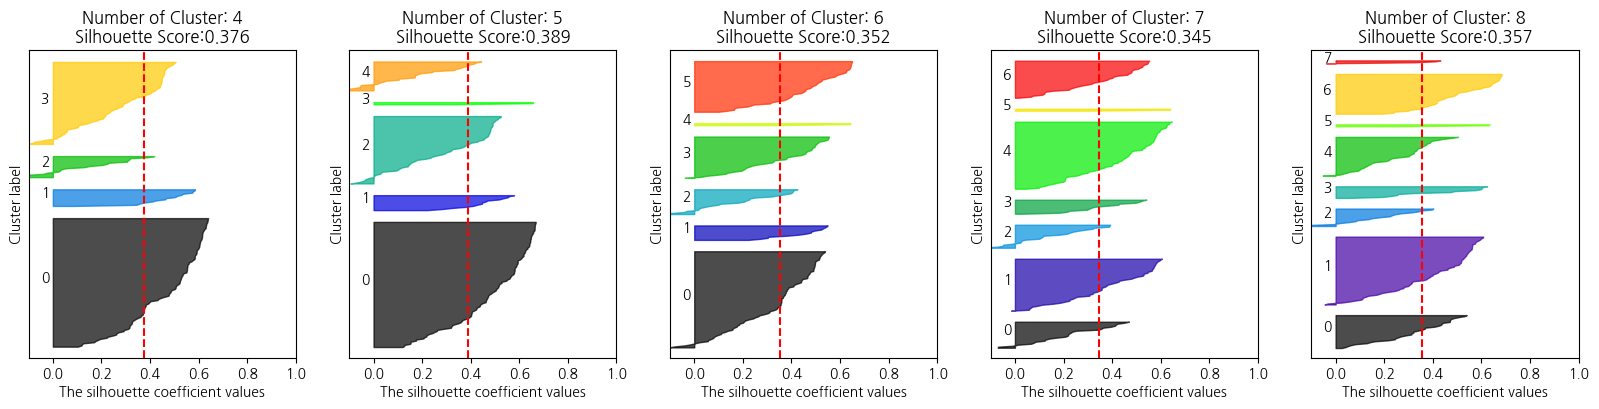

In [11]:
visualize_silhouette([4,5,6,7,8],X_pca)

In [12]:
from sklearn.cluster import KMeans

# KMeans를 적용하여 군집 레이블 생성 (여기서는 PCA 적용 후 데이터를 사용)
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_pca)

# 원본 데이터프레임(selected_df)에 군집 레이블 열 추가
df['cluster_label'] = labels + 1
df

,지역명,식당 평가 지표,관광 소비 지표,치안 평가 지표,교통접근성 평가 지표,cluster_label
0,강원 강릉시,440.568338,1866.0,3.7385,0.036538,1
1,강원 고성군,287.425295,530.0,3.7772,0.016667,1
2,강원 동해시,324.271060,393.0,3.4289,2.183333,1
3,강원 삼척시,239.659512,507.0,3.3425,0.118787,1
4,강원 속초시,789.962512,1655.0,3.9321,1.942857,1
...,...,...,...,...,...,...
223,충북 진천군,208.586352,526.0,2.6908,1.845209,3
224,충북 청주시,349.452156,1360.5,3.0680,3.682253,1
225,충북 충주시,188.146014,1240.0,3.4283,1.767040,1
226,서울 도봉구,562.958880,914.0,2.7175,4.250000,3


In [13]:
df.columns

Index(['지역명', '식당 평가 지표', '관광 소비 지표', '치안 평가 지표', '교통접근성 평가 지표',
       'cluster_label'],
      dtype='object')

In [14]:
clustered_df = df.groupby('cluster_label')[['식당 평가 지표', '관광 소비 지표', '치안 평가 지표', '교통접근성 평가 지표']].mean()

In [15]:
# 표준화 및 결과 확인
scaler = StandardScaler()
cluster_results = scaler.fit_transform(clustered_df)
results_df = pd.DataFrame(cluster_results)
results_df.columns = ['식당 평가 지표', '관광 소비 지표', '치안 평가 지표', '교통접근성 평가 지표']
results_df.index = clustered_df.index
results_df

,식당 평가 지표,관광 소비 지표,치안 평가 지표,교통접근성 평가 지표
cluster_label,,,,
1,-0.940552,-1.028405,0.703980,-0.729303
2,1.893009,1.721930,0.552736,-0.570554
3,-0.641440,-0.717077,-1.960654,-0.627903
4,0.034317,0.492850,0.120704,1.936041
5,-0.345335,-0.469298,0.583234,-0.008280


## cluster 1: 혼여행이 안전한 자연경관을 위해 방문할 수 있는 지역
- 혼자 밥을 먹을 수 있는 식당에 대한 평가는 낮은 지역임
- 관광 소비도 매우 낮은 편으로 전통적으로 어트랙션을 갖춘 관광지가 아닌 자연경관을 위해 방문하는 지역으로 유추됨
- 대중교통이 잘 갖춰지지 않은 지역이라 차량으로 방문이 필요한 지역임
- 치안에 대한 평가는 상대적으로 매우 우수하기에 안전하게 놀 수 있을 것으로 보임

## cluster 2: 놀거리, 먹거리 가득한 관광 지역
- 해당 지역은 식당에 대한 평가가 매우 우수한 편
- 관광 소비가 압도적으로 나타나는데, 이는 소비를 이끄는 어트랙션이 많은 지역으로 생각됨 -> 전통적인 관광지
- 치안도 전반적으로 우수함
- 다만 대중교통접근성이 좋지 못한 몇 지역이 포함되어 있는 것으로 생각됨

## cluster 3: 관광 목적으로 방문하기 아쉬운 지역
- 혼자 밥을 먹을 수 있는 식당에 대한 평가가 전반적으로 낮고, 관광 소비도 매우 적음
- 치안이 특히 좋지 않은데 교통사고,화재,강력범죄 등의 사건 사고 빈도가 높은 곳이 포함되어 있는 것으로 추정됨
- 대중 교통으로 다니기도 어려운 지역들이 포함되어있는 것으로 생각됨
- 즉, 전반적으로 혼여행 목적으로 방문하기에는 아쉬운 지역

## cluster 4: 대중교통을 이용해 편하게 여행하고 싶을 때 방문하기 좋은 지역
- 관광소비지표를 볼 때 어느 정도 놀거리가 갖춰져 있는 것을 유추할 수 있음
- 대중교통접근성 평가지표가 매우 우수하여 차량 없이 대중교통을 이용하여 지역을 순회하고 싶은 여행객에게 좋은 관광지로 보임

## cluster 5: 숨어있는 맛집을 찾으며 혼자 안전하게 여행하기 좋은 지역
- 전반적으로 모든 지표에 대해 평이함
- 식당 평가지표가 나쁘지 않고 치안에 대한 평가가 좋음
- 대중교통 접근성도 나쁘지 않기 때문에 혼자 숨겨진 맛집을 찾으며 편하게 여행하기 좋은 지역이라고 생각됨

In [16]:
df[df['cluster_label'] == 1].지역명.unique()

array(['강원 강릉시', '강원 고성군', '강원 동해시', '강원 삼척시', '강원 속초시', '강원 양양군',
       '강원 영월군', '강원 원주시', '강원 인제군', '강원 춘천시', '강원 태백시', '강원 평창군',
       '강원 홍천군', '강원 횡성군', '경기 가평군', '경기 광주시', '경기 동두천시', '경기 안산시',
       '경기 안성시', '경기 여주시', '경기 연천군', '경기 평택시', '경기 포천시', '경남 고성군',
       '경남 김해시', '경남 남해군', '경남 밀양시', '경남 사천시', '경남 산청군', '경남 양산시',
       '경남 의령군', '경남 진주시', '경남 창녕군', '경남 통영시', '경남 하동군', '경남 함안군',
       '경남 함양군', '경남 합천군', '경북 경산시', '경북 경주시', '경북 고령군', '경북 구미시',
       '경북 김천시', '경북 문경시', '경북 봉화군', '경북 상주시', '경북 성주군', '경북 안동시',
       '경북 영덕군', '경북 영주시', '경북 영천시', '경북 예천군', '경북 울진군', '경북 의성군',
       '경북 청도군', '경북 청송군', '경북 포항시', '광주 광산구', '대구 군위군', '대구 남구',
       '대전 대덕구', '부산 금정구', '서울 강북구', '서울 동대문구', '서울 중랑구', '인천 강화군',
       '전남 강진군', '전남 고흥군', '전남 나주시', '전남 목포시', '전남 보성군', '전남 순천시',
       '전남 신안군', '전남 영암군', '전남 완도군', '전남 장흥군', '전남 진도군', '전남 함평군',
       '전남 해남군', '전북 고창군', '전북 군산시', '전북 김제시', '전북 남원시', '전북 부안군',
       '전북 순창군', '전북 익산시', '전북 장수군', '전북 정읍시', '충남 공주시', '충남 

In [17]:
df[df['cluster_label'] == 2].지역명.unique()

array(['부산 수영구', '부산 해운대구', '서울 강남구', '서울 강서구', '서울 관악구', '서울 마포구',
       '서울 서초구', '서울 송파구', '서울 영등포구', '서울 용산구', '서울 종로구', '서울 중구',
       '전남 여수시', '제주도 서귀포시', '제주도 제주시'], dtype=object)

In [18]:
df[df['cluster_label'] == 3].지역명.unique()

array(['강원 양구군', '강원 정선군', '강원 철원군', '강원 화천군', '경기 고양시', '경기 과천시',
       '경기 광명시', '경기 구리시', '경기 군포시', '경기 김포시', '경기 남양주시', '경기 성남시',
       '경기 수원시', '경기 시흥시', '경기 안양시', '경기 양주시', '경기 양평군', '경기 오산시',
       '경기 용인시', '경기 의왕시', '경기 의정부시', '경기 이천시', '경기 파주시', '경기 하남시',
       '경기 화성시', '경남 거제시', '경남 거창군', '경남 창원시', '경북 영양군', '경북 울릉군',
       '경북 칠곡군', '광주 남구', '대구 달성군', '대구 수성구', '대전 유성구', '부산 기장군', '부산 남구',
       '부산 북구', '서울 강동구', '서울 광진구', '서울 구로구', '서울 노원구', '서울 동작구',
       '서울 서대문구', '서울 성동구', '서울 성북구', '서울 양천구', '서울 은평구', '울산 동구',
       '울산 북구', '울산 울주군', '인천 계양구', '인천 동구', '인천 연수구', '인천 옹진군', '전남 곡성군',
       '전남 광양시', '전남 구례군', '전남 담양군', '전남 무안군', '전남 영광군', '전남 장성군',
       '전남 화순군', '전북 무주군', '전북 완주군', '전북 임실군', '전북 전주시', '전북 진안군',
       '충남 계룡시', '충북 보은군', '충북 증평군', '충북 진천군', '서울 도봉구'], dtype=object)

In [19]:
df[df['cluster_label'] == 4].지역명.unique()

array(['대구 동구', '인천 서구', '인천 중구'], dtype=object)

In [20]:
df[df['cluster_label'] == 5].지역명.unique()

array(['경기 부천시', '광주 동구', '광주 북구', '광주 서구', '대구 달서구', '대구 북구', '대구 서구',
       '대구 중구', '대전 동구', '대전 서구', '대전 중구', '부산 강서구', '부산 동구', '부산 동래구',
       '부산 부산진구', '부산 사상구', '부산 사하구', '부산 서구', '부산 영도구', '부산 중구',
       '서울 금천구', '울산 남구', '울산 중구', '인천 남동구', '인천 미추홀구', '인천 부평구',
       '부산 연제구'], dtype=object)

In [38]:
# 종합 평가 지표 산출

# 표준화
df_scaled = scaler.fit_transform(df_set)
df_scaled = pd.DataFrame(df_scaled)

# 컬럼명, 인덱스 부여
df_scaled.columns = ['식당 평가 지표','관광 소비 지표','치안 평가 지표','교통접근성 평가 지표']
df_scaled.index = df_set.index

# 종합 평가지표 계산
df_scaled['종합 평가 지표'] = (df_scaled.loc[:,'식당 평가 지표'] + df_scaled.loc[:,'관광 소비 지표'] + df_scaled.loc[:,'치안 평가 지표'] + df_scaled.loc[:,'교통접근성 평가 지표']) / 4

df_scaled = df_scaled.reset_index()
df_scaled

,지역명,식당 평가 지표,관광 소비 지표,치안 평가 지표,교통접근성 평가 지표,종합 평가 지표
0,강원 강릉시,0.253451,0.207541,1.228496,-0.551336,0.284538
1,강원 고성군,-0.449609,-0.463424,1.294411,-0.552608,-0.042808
2,강원 동해시,-0.280455,-0.532228,0.701175,-0.413865,-0.131343
3,강원 삼척시,-0.668896,-0.474975,0.554015,-0.546069,-0.283981
4,강원 속초시,1.857475,0.101573,1.558241,-0.429264,0.772006
...,...,...,...,...,...,...
223,충북 진천군,-0.811549,-0.465433,-0.555982,-0.435517,-0.567120
224,충북 청주시,-0.164852,-0.046331,0.086478,-0.317882,-0.110647
225,충북 충주시,-0.905388,-0.106848,0.700153,-0.440523,-0.188152
226,서울 도봉구,0.815330,-0.270572,-0.510505,-0.281526,-0.061818


In [40]:
df_scaled['클러스터'] = df['cluster_label']
df_scaled

,지역명,식당 평가 지표,관광 소비 지표,치안 평가 지표,교통접근성 평가 지표,종합 평가 지표,클러스터
0,강원 강릉시,0.253451,0.207541,1.228496,-0.551336,0.284538,1
1,강원 고성군,-0.449609,-0.463424,1.294411,-0.552608,-0.042808,1
2,강원 동해시,-0.280455,-0.532228,0.701175,-0.413865,-0.131343,1
3,강원 삼척시,-0.668896,-0.474975,0.554015,-0.546069,-0.283981,1
4,강원 속초시,1.857475,0.101573,1.558241,-0.429264,0.772006,1
...,...,...,...,...,...,...,...
223,충북 진천군,-0.811549,-0.465433,-0.555982,-0.435517,-0.567120,3
224,충북 청주시,-0.164852,-0.046331,0.086478,-0.317882,-0.110647,1
225,충북 충주시,-0.905388,-0.106848,0.700153,-0.440523,-0.188152,1
226,서울 도봉구,0.815330,-0.270572,-0.510505,-0.281526,-0.061818,3


In [41]:
df_scaled.to_csv('군집분석결과_시각화용.csv',index=False)